2025-08-18 08:45:41.499797: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755506741.526128      90 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755506741.533627      90 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Number of train samples: 2930
Number of validation samples: 366
Number of test samples: 366
There are 2930 training images.
There are 366 validation images.
There are 366 test images.


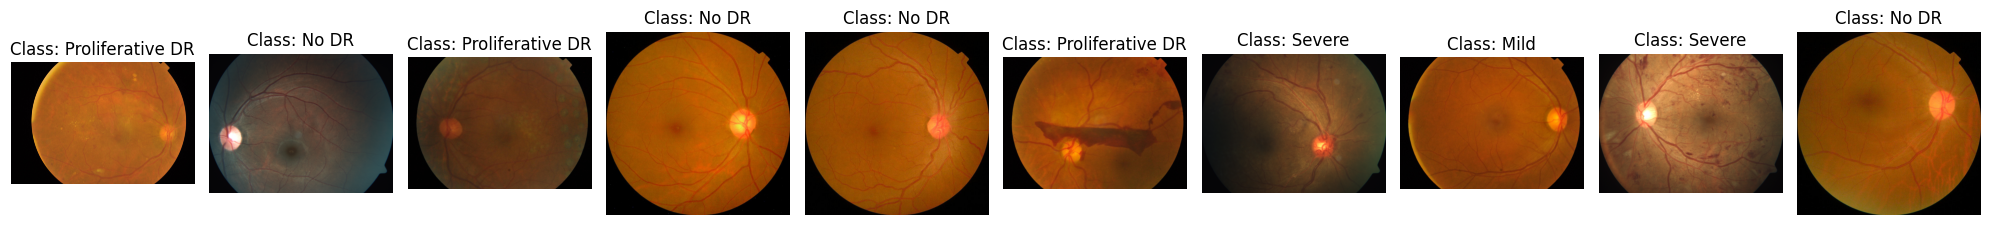

In [1]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, cohen_kappa_score
from keras.models import Model
from keras import optimizers, applications
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
import cv2
import matplotlib.image as mpimg
warnings.filterwarnings("ignore")
# Load the CSV files
train_data = pd.read_csv("/kaggle/input/aptos2019/train_1.csv")
valid_data = pd.read_csv("/kaggle/input/aptos2019/valid.csv")
test_data = pd.read_csv("/kaggle/input/aptos2019/test.csv")

# Print the number of samples in each dataset
print('Number of train samples:', train_data.shape[0])
print('Number of validation samples:', valid_data.shape[0])
print('Number of test samples:', test_data.shape[0])


import os

# Define the image directories
train_image_dir = "/kaggle/input/aptos2019/train_images/train_images"
val_image_dir = "/kaggle/input/aptos2019/val_images/val_images"
test_image_dir = "/kaggle/input/aptos2019/test_images/test_images"

# Function to count images in a directory
def count_images(directory):
    return len([file for file in os.listdir(directory) if file.endswith(('.png', '.jpg', '.jpeg'))])

# Count images in each directory
train_image_count = count_images(train_image_dir)
val_image_count = count_images(val_image_dir)
test_image_count = count_images(test_image_dir)

# Print the counts
print(f'There are {train_image_count} training images.')
print(f'There are {val_image_count} validation images.')
print(f'There are {test_image_count} test images.')


import matplotlib.pyplot as plt
import random
import matplotlib.image as mpimg

# Class labels dictionary
class_labels = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative DR"
}

# Check some random images from the training set to ensure they are correctly labeled
random_samples = random.sample(list(train_data['id_code']), 10)

plt.figure(figsize=(20, 10))
for i, image_id in enumerate(random_samples):
    # Image file path
    img_path = os.path.join(train_image_dir, f"{image_id}.png")  # Adjust extension if necessary
    img = mpimg.imread(img_path)
    
    # Get the class label for the image
    image_class = train_data.loc[train_data['id_code'] == image_id, 'diagnosis'].values[0]
    class_name = class_labels.get(image_class, "Unknown")
    
    # Plot the image
    plt.subplot(1, 10, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Class: {class_name}")

plt.tight_layout()
plt.show()


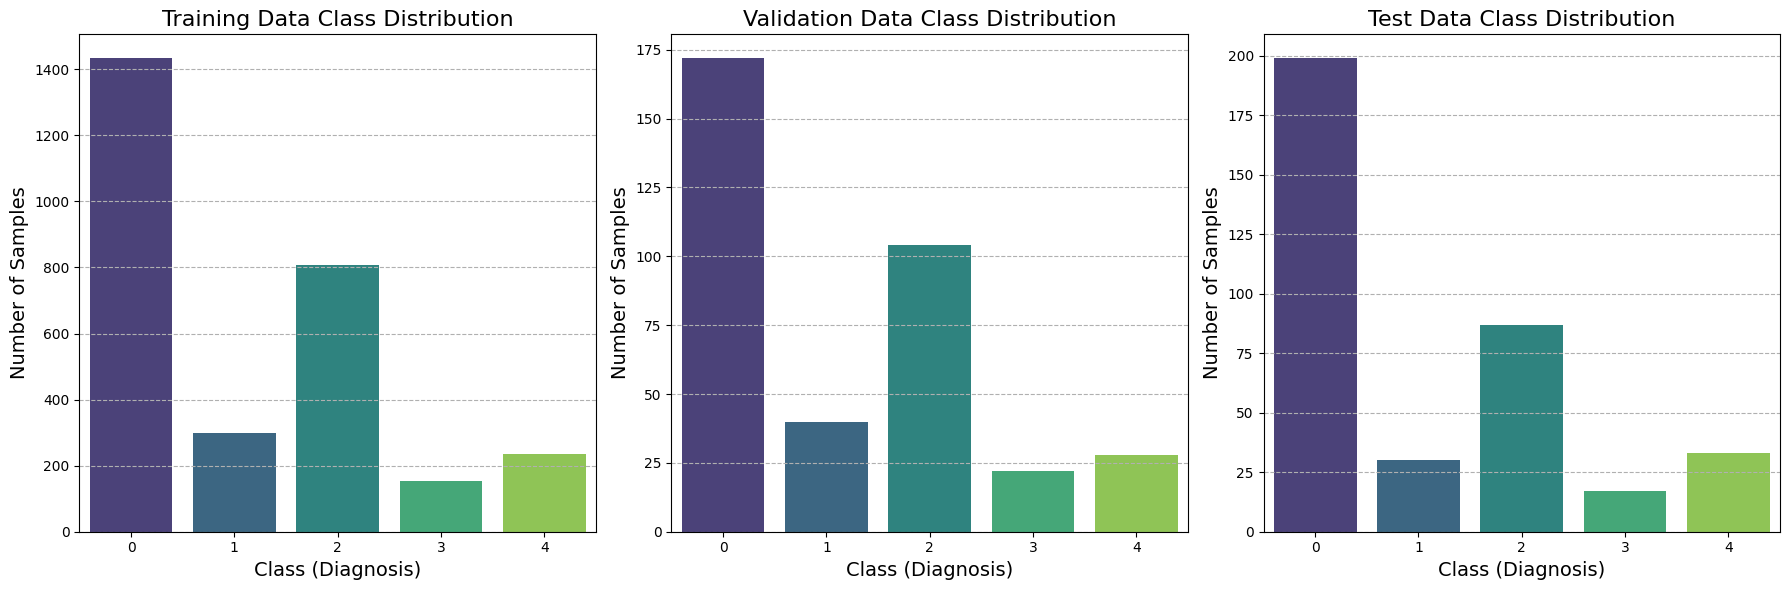

Training Data Class Distribution:
diagnosis
0    1434
1     300
2     808
3     154
4     234
Name: count, dtype: int64

Validation Data Class Distribution:
diagnosis
0    172
1     40
2    104
3     22
4     28
Name: count, dtype: int64

Test Data Class Distribution:
diagnosis
0    199
1     30
2     87
3     17
4     33
Name: count, dtype: int64


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load the CSV files (if not already loaded)
train_data = pd.read_csv("/kaggle/input/aptos2019/train_1.csv")
valid_data = pd.read_csv("/kaggle/input/aptos2019/valid.csv")
test_data = pd.read_csv("/kaggle/input/aptos2019/test.csv")

# Count the occurrences of each class in the training, validation, and test datasets
train_class_counts = train_data['diagnosis'].value_counts().sort_index()
val_class_counts = valid_data['diagnosis'].value_counts().sort_index()
test_class_counts = test_data['diagnosis'].value_counts().sort_index()

# Set up the bar charts for each dataset
plt.figure(figsize=(18, 6))

# Training Data
plt.subplot(1, 3, 1)
sns.barplot(x=train_class_counts.index, y=train_class_counts.values, palette='viridis')
plt.title('Training Data Class Distribution', fontsize=16)
plt.xlabel('Class (Diagnosis)', fontsize=14)
plt.ylabel('Number of Samples', fontsize=14)
plt.xticks(ticks=train_class_counts.index, labels=train_class_counts.index)
plt.grid(axis='y', linestyle='--')

# Validation Data
plt.subplot(1, 3, 2)
sns.barplot(x=val_class_counts.index, y=val_class_counts.values, palette='viridis')
plt.title('Validation Data Class Distribution', fontsize=16)
plt.xlabel('Class (Diagnosis)', fontsize=14)
plt.ylabel('Number of Samples', fontsize=14)
plt.xticks(ticks=val_class_counts.index, labels=val_class_counts.index)
plt.grid(axis='y', linestyle='--')

# Test Data
plt.subplot(1, 3, 3)
sns.barplot(x=test_class_counts.index, y=test_class_counts.values, palette='viridis')
plt.title('Test Data Class Distribution', fontsize=16)
plt.xlabel('Class (Diagnosis)', fontsize=14)
plt.ylabel('Number of Samples', fontsize=14)
plt.xticks(ticks=test_class_counts.index, labels=test_class_counts.index)
plt.grid(axis='y', linestyle='--')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

# Print the number of samples for each class in the training data
print("Training Data Class Distribution:")
print(train_class_counts)
print("\nValidation Data Class Distribution:")
print(val_class_counts)
print("\nTest Data Class Distribution:")
print(test_class_counts)


In [3]:
pip install imbalanced-learn


Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from imblearn.over_sampling import SMOTE

# Define image dimensions and paths
IMG_SIZE = 100
train_image_dir = "/kaggle/input/aptos2019/train_images/train_images"

# Load CSV file
train_data = pd.read_csv("/kaggle/input/aptos2019/train_1.csv")

# Preprocess the images (this function remains unchanged)
def load_and_preprocess_image(image_id):
    img_path = os.path.join(train_image_dir, f"{image_id}.png")
    img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = img_to_array(img) / 255.0
    return img_array

# Convert labels to numeric format and prepare features
X = np.array([load_and_preprocess_image(image_id) for image_id in train_data['id_code']])
y = train_data['diagnosis'].values

# Apply SMOTE to the labels
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X.reshape(X.shape[0], -1), y)  # Flatten images for SMOTE

# Convert back to the original image shape
X_resampled = X_resampled.reshape(-1, IMG_SIZE, IMG_SIZE, 3)

# Convert labels to one-hot encoded format
y_resampled = to_categorical(y_resampled, num_classes=5)

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")


Shape of X_train: (5736, 100, 100, 3)
Shape of y_train: (5736, 5)


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define the CNN model
def create_cnn_model(input_shape):
    model = Sequential()

    # First convolutional layer
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    
    # Second convolutional layer
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Third convolutional layer
    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Flatten and fully connected layer
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))  # Add dropout to avoid overfitting

    # Output layer
    model.add(Dense(5, activation='softmax'))  # 5 classes for diagnosis

    return model

# Create the CNN model
model = create_cnn_model(input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Define callbacks for early stopping and saving the best model
callbacks = [
    EarlyStopping(patience=15, monitor='val_accuracy', restore_best_weights=True),
    ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_accuracy')
]

# Train the model
history = model.fit(X_train, y_train, 
                    validation_data=(X_val, y_val),
                    epochs=40, 
                    batch_size=32, 
                    callbacks=callbacks)


2025-08-18 08:55:54.023761: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/40
180/180 ━━━━━━━━━━━━━━━━━━━━ 51s 267ms/step - accuracy: 0.3837 - loss: 1.3905 - val_accuracy: 0.5732 - val_loss: 1.0803
Epoch 2/40
180/180 ━━━━━━━━━━━━━━━━━━━━ 49s 273ms/step - accuracy: 0.5581 - loss: 1.0896 - val_accuracy: 0.6611 - val_loss: 0.9122
Epoch 3/40
180/180 ━━━━━━━━━━━━━━━━━━━━ 47s 263ms/step - accuracy: 0.6435 - loss: 0.8922 - val_accuracy: 0.7252 - val_loss: 0.7261
Epoch 4/40
180/180 ━━━━━━━━━━━━━━━━━━━━ 48s 264ms/step - accuracy: 0.7243 - loss: 0.7154 - val_accuracy: 0.7810 - val_loss: 0.6094
Epoch 5/40
180/180 ━━━━━━━━━━━━━━━━━━━━ 47s 261ms/step - accuracy: 0.7857 - loss: 0.5689 - val_accuracy: 0.8257 - val_loss: 0.5500
Epoch 6/40
180/180 ━━━━━━━━━━━━━━━━━━━━ 48s 268ms/step - accuracy: 0.8369 - loss: 0.4428 - val_accuracy: 0.8550 - val_loss: 0.4188
Epoch 7/40
180/180 ━━━━━━━━━━━━━━━━━━━━ 55s 307ms/step - accuracy: 0.8739 - loss: 0.3635 - val_accuracy: 0.8898 - val_loss: 0.3586
Epoch 8/40
180/180 ━━━━━━━━━━━━━━━━━━━━ 50s 277ms/step - accuracy: 0.9008 - loss: 0

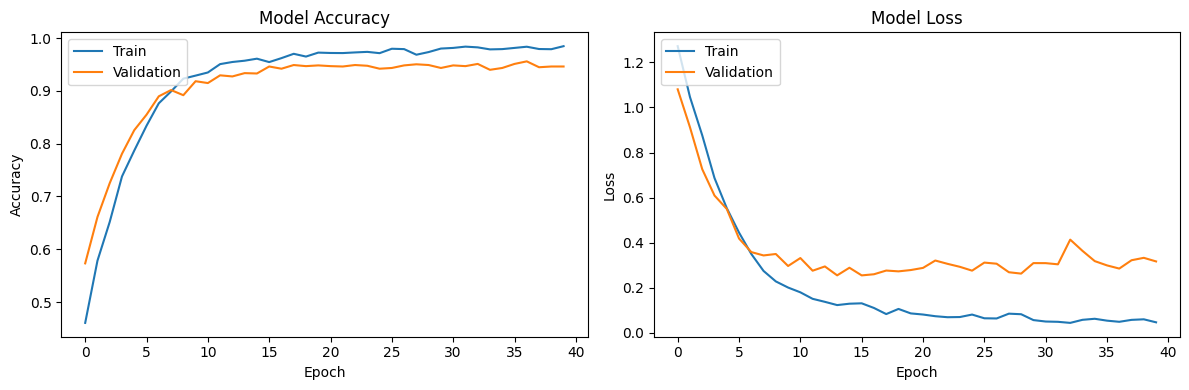

In [6]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()


In [8]:
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Accuracy: {val_acc*100:.2f}%")


Validation Accuracy: 95.61%


In [9]:
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
print(f"Training Accuracy: {train_acc*100:.2f}%")


Training Accuracy: 99.37%


45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step


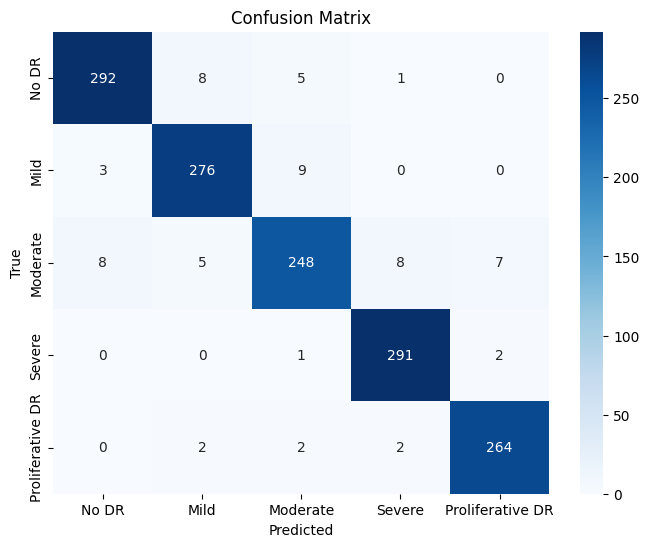

In [10]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Convert one-hot encoded y_val back to class labels
y_true = np.argmax(y_val, axis=1)

# Predictions
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"],
            yticklabels=["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


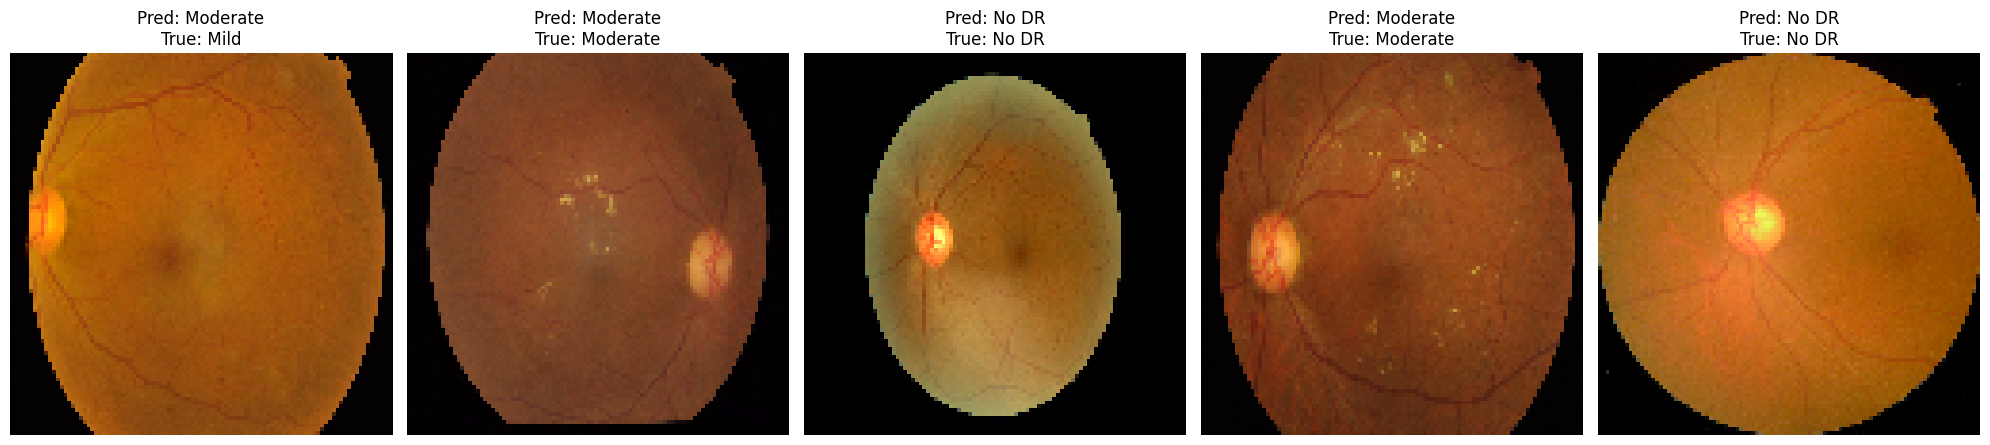

In [12]:
import random

# Class labels dictionary
class_labels = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative DR"
}

# Preprocess function for test images
def load_and_preprocess_test_image(image_id):
    img_path = os.path.join(test_image_dir, f"{image_id}.png")
    img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = img_to_array(img) / 255.0
    return img_array

# Pick random test samples
random_samples = random.sample(list(test_data['id_code']), 5)  # choose 5 random test images

plt.figure(figsize=(20, 10))
for i, image_id in enumerate(random_samples):
    # Load and preprocess image
    img_array = load_and_preprocess_test_image(image_id)

    # Predict (add batch dimension)
    pred = model.predict(np.expand_dims(img_array, axis=0))
    pred_class = np.argmax(pred)

    # Try to fetch true label (if available in test.csv)
    if 'diagnosis' in test_data.columns:
        true_class = test_data.loc[test_data['id_code'] == image_id, 'diagnosis'].values[0]
        true_name = class_labels[true_class]
    else:
        true_name = "Unknown"  # Kaggle test usually doesn’t have labels

    pred_name = class_labels[pred_class]

    # Plot image
    plt.subplot(1, 5, i + 1)
    plt.imshow(img_array)
    plt.axis("off")
    plt.title(f"Pred: {pred_name}\nTrue: {true_name}")

plt.tight_layout()
plt.show()
